In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os
import json
import pyvista as pv
from scipy.ndimage import distance_transform_edt

In [ ]:
# ========================================================================
# 1. Read config.json -> native occupancy grid + threshold + domain size
# ========================================================================

def read_config(config_path: str | Path) -> dict:
    """
    Read the configuration files for the dataset and return a dictionary of parameters.
    """
    config_path = Path(config_path)
    with open(config_path, "r") as f:
        config = json.load(f)
    
    return {
        "occupancy_grid": np.array(config["occupancy_grid"], dtype=np.float32),
        "threshold": float(config["threshold"]),
        "grid_nx": int(config["grid_nx"]),
        "grid_ny": int(config["grid_ny"]),
        "domain_length": float(config["domain_length"]),
        "domain_height": float(config["domain_height"]),
    }

# ========================================================================
# 2. Read MOOSE Exodus II results file -> coordinates + u, v, p, T fields
# ========================================================================

def _extract_valid_blocks(block) -> list:
    """
    Recursively collect all non-empty leaf datasets from a PyVista MultiBlock tree.
    A block is 'valid' if it has at least one point and one cell.
    """
    datasets = []
    if isinstance(block, pv.MultiBlock):
        for i in range(block.n_blocks):
            datasets.extend(_extract_valid_blocks(block[i]))
    else:
        if block is None:
            return []
        if block.n_points == 0 or block.n_cells == 0:
            return []
        datasets.append(block)
    return datasets

def read_moose_results(
        exodus_path: str | Path,
) -> dict[str, np.ndarray]:
    """
    Read a MOOSE Exodus II results file and map the fields onto the
    reference grid defined by GeometryConfig.

    Parameters
    ----------
    exodus_path : str | Path
        Path to the Exodus II file.

    Returns
    -------
    dict with keys: 'coords', 'u', 'v', 'p', 'T'
    """
    # Read the Exodus II file using PyVista
    exodus_path = str(exodus_path)
    reader = pv.get_reader(exodus_path)
    reader.set_active_time_value(reader.time_values[-1])  # last time step
    mb = reader.read()

    # Filter out empty blocks before mergine - avoids PyVista warnings
    valid_blocks = _extract_valid_blocks(mb)
    if not valid_blocks:
        raise RuntimeError(
            f"No non-empty blocks found in {exodus_path}. "
            "The simulation may have failed or written an empty results file."
        )
    
    # Combine the valid blocks into a single mesh and convert cell data to point data
    mesh = pv.MultiBlock(valid_blocks).combine()
    mesh = mesh.cell_data_to_point_data()

    # Extract the relevant fields from the mesh
    coords = np.array(mesh.points, dtype=np.float64)  # shape (N, 3)
    vel = np.array(mesh["vel_"], dtype=np.float64)  # shape (N, 3)
    u = vel[:, 0]  # x-velocity
    v = vel[:, 1]  # y-velocity
    p = np.array(mesh["p"], dtype=np.float64)  # shape (N,)
    T = np.array(mesh["T"], dtype=np.float64)  # shape (N,)
    moose_results = {
        "coords": coords,
        "u": u,
        "v": v,
        "p": p,
        "T": T,
    }
    return moose_results

# =========================================================================
# 3. Upscale native occupancy grid and validate size match to MOOSE results
# =========================================================================

def compare_scale(node_points: np.ndarray, expected_dx: float, expected_dy: float, scale_candidates=(1, 2, 4, 8, 16, 32)):
    # code to compare the scale of the occupancy grid and MOOSE results
    x, y = node_points[:, 0], node_points[:, 1]
    ux = np.unique(x)
    uy = np.unique(y)
    observed_dx = np.min(np.diff(np.sort(ux))) if len(ux) > 1 else float("nan")
    observed_dy = np.min(np.diff(np.sort(uy))) if len(uy) > 1 else float("nan")
    factor_x = expected_dx / observed_dx if observed_dx else float("nan")
    factor_y = expected_dy / observed_dy if observed_dy else float("nan")
    
    for scale in scale_candidates:
        if np.isclose(factor_x, scale, rtol=1e-3) and np.isclose(factor_y, scale, rtol=1e-3):
            return scale
    return float("nan")

def upscale_occupancy_grid(occupancy_grid: np.ndarray, scale: int) -> np.ndarray:
    """subdivides each cell into scale x scale cells, preserving the occupancy value (0 or 1)"""
    return np.kron(occupancy_grid, np.ones((scale, scale), dtype=occupancy_grid.dtype))

# ========================================================================
# 4. Compute SDF and Normalized Coordinates
# ========================================================================

def compute_sdf(occupancy_grid: np.ndarray, dx: float, dy: float, domain_height: float) -> np.ndarray:
    """
    Physical-distance signed distance function: positive in fluid, negative in solid, normalized by domain_height.
    """
    fluid = occupancy_grid == 1
    dist_to_solid = distance_transform_edt(fluid, sampling=(dy, dx))  # distance from fluid px to nearest solid px
    dist_to_fluid = distance_transform_edt(~fluid, sampling=(dy, dx))
    sdf = np.where(fluid, dist_to_solid, -dist_to_fluid)
    return (sdf / domain_height).astype(np.float32)

def compute_normalized_coords(nx: int, ny: int, dx: float, dy: float, domain_height: float):
    """Cell-center x, y coordinates, both normalized by domain_height (y in [0,1] and x in [0, L/H])"""
    x = (np.arange(nx) + 0.5) * dx / domain_height
    y = (np.arange(ny) + 0.5) * dy / domain_height
    xx, yy = np.meshgrid(x, y) # each (ny, nx)
    return xx.astype(np.float32), yy.astype(np.float32)

# ========================================================================
# 5. Interpolate MOOSE results onto cell centers via 4-corner avg
# ========================================================================

def filter_to_corner_nodes(node_points: np.ndarray, node_fields: dict, dx: float, dy: float, rtol: float=1e-3):
    """ 
    Keeps only nodes that land on the element-corner grid (spacing dx, dy),
    discarding mid-edge/mid-face nodes that second-order (quadratic) elements
    add at the midpoint of each edge.

    Args:
        node_points: (N, 2) array of (x, y) mesh node coordinates
        node_fields: dict of field_name -> (N,) array, same indexing as node_points
        dx, dy: expected grid spacing in x and y
        rtol: relative tolerance for snapping check
    Returns: (filtered_points, filtered_fields) with only corner nodes kept
    """
    x, y = node_points[:, 0], node_points[:, 1]
    gi_raw = x / dx
    gj_raw = y / dy
    is_corner = (np.abs(gi_raw - np.round(gi_raw)) < rtol) & (np.abs(gj_raw - np.round(gj_raw)) < rtol)

    filtered_points = node_points[is_corner]
    filtered_fields = {name: field[is_corner] for name, field in node_fields.items()}
    return filtered_points, filtered_fields

def build_node_lookup(node_points: np.ndarray, dx: float, dy: float, rtol: float=1e-3) -> dict:
    """
    Maps each mesh node onto its (grid_i, grid_j) grid-line intersection index,
    snapping by rounding to the nearest multiple of dx, dy. Valid because the mesh
    is locked to the occupancy grid (blocky boundary).
    """
    x, y = node_points[:, 0], node_points[:, 1]
    gi = np.round(x / dx).astype(int)
    gj = np.round(y / dy).astype(int)

    # sanity check: snapped coordinates should closely match actual node coords
    snap_err_x = np.abs(gi * dx - x)
    snap_err_y = np.abs(gj * dy - y)
    tol = rtol * max(dx, dy)
    if np.any(snap_err_x > tol) or np.any(snap_err_y > tol):
        raise ValueError("Node coordinates do not align with grid lines within tolerance.")
    
    lookup = {}
    for idx, (i, j) in enumerate(zip(gi, gj)):
        lookup[(i, j)] = idx
    return lookup

def interpolate_nodes_to_cell_centers(node_fields: dict, node_lookup: dict, nx: int, ny: int) -> dict:
    """
    for each cell (ix, iy), averages the 4 corner nodes 
    (ix, iy), (ix+1, iy), (ix, iy+1), (ix+1, iy+1) to get the cell-center value.
    """
    field_names = [k for k in node_fields.keys() if k != "coords"]
    out = {name: np.full((ny, nx), np.nan, dtype=np.float32) for name in field_names}

    for iy in range(ny):
        for ix in range(nx):
            corners = [(ix, iy), (ix + 1, iy), (ix, iy + 1), (ix + 1, iy + 1)]
            node_ids = [node_lookup.get(corner) for corner in corners]
            if any(n is None for n in node_ids):
                continue  # skip cells with missing corners
            for name in field_names:
                vals = node_fields[name][node_ids]
                out[name][iy, ix] = np.mean(vals)
    return out

# ========================================================================
# 6. Assemble the tidy per-cell dataframe from the MOOSE results and the occupancy grid
# ========================================================================

def assemble_dataframe(geometry_id: str, occupancy: np.ndarray, sdf: np.ndarray, x: np.ndarray, y: np.ndarray,
                       cell_fields: dict) -> pd.DataFrame:
    """
    Flattens (ny, nx) arrays into a tidy dataframe: one row per cell.
    Columns: geometry_id, ix, iy, occupancy, sdf, x, y, u, v, p, T.
    """
    ny, nx = occupancy.shape
    ix_grid, iy_grid = np.meshgrid(np.arange(nx), np.arange(ny))

    data = {
        "geometry_id": geometry_id,
        "ix": ix_grid.flatten(),
        "iy": iy_grid.flatten(),
        "occupancy": occupancy.flatten(),
        "sdf": sdf.flatten(),
        "x": x.flatten(),
        "y": y.flatten(),
    }
    for name, field in cell_fields.items():
        data[name] = field.flatten()
    return pd.DataFrame(data)

# ========================================================================
# 7. Top-level: build_dataset
# ========================================================================

def build_dataset(config_dir: str, results_dir: str, sim_scale: int, output_dir: str, overwrite: bool=False, verbose: bool=False) -> dict:
    """
    For each geometry in config_dir, read the occupancy grid and MOOSE results, upscale the occupancy grid,
    compute the SDF and normalized coordinates, interpolate the MOOSE results onto cell centers, 
    and assemble the data into a tidy dataframe. Save the dataframe as a CSV file in output_dir.
    """ 
    config_dir = Path(config_dir)
    results_dir = Path(results_dir)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    summary = {"built": [], "skipped": [], "failed": []}

    file_root = "hx_200x100-0.010m-t"

    num_geometries = len(list(config_dir.glob("*.json")))
    for i in range(num_geometries):
        if verbose:
            print(f"Processing geometry {i+1}/{num_geometries}...")
            
        # Build filenames for the current geometry
        geometry_id = f"{file_root}{i:04d}"
        config_path = config_dir / f"{geometry_id}.json"
        results_path = results_dir / f"{geometry_id}.e"
        output_path = output_dir / f"{geometry_id}.parquet"

        # Skip if output already exists and overwrite is False
        if output_path.exists() and not overwrite:
            summary["skipped"].append(geometry_id)
            continue

        # Skip any geometries missing a config or results file
        if not config_path.exists() or not results_path.exists():
            summary["skipped"].append(geometry_id)
            continue

        try:
            # Read config and extract occupancy grid and domain parameters
            config = read_config(config_path)
            occupancy_grid = config["occupancy_grid"]
            Lx, Ly = config["domain_length"], config["domain_height"]
            grid_nx, grid_ny = config["grid_nx"], config["grid_ny"]
            dx, dy = Lx / grid_nx, Ly / grid_ny

            # Read MOOSE results and extract node fields
            moose_results = read_moose_results(results_path)
            node_fields = {k: v for k, v in moose_results.items() if k != "coords"}

            # Upscale occupancy grid if sim_scale > 1 and compute binary occupancy
            if sim_scale > 1.0:
                occupancy_grid = upscale_occupancy_grid(occupancy_grid, sim_scale)
                dx, dy = dx / sim_scale, dy / sim_scale
            else:
                corner_points, corner_fields = filter_to_corner_nodes(moose_results["coords"], node_fields, dx, dy)
                moose_results = {"coords": corner_points, **corner_fields}
            occupancy_binary = (occupancy_grid < config["threshold"]).astype(np.float32)

            # Compute SDF and normalized coordinates
            ny_target, nx_target = occupancy_binary.shape
            sdf = compute_sdf(occupancy_binary, dx, dy, Ly)
            x_coords, y_coords = compute_normalized_coords(nx_target, ny_target, dx, dy, Ly)

            # Interpolate MOOSE results onto cell centers
            node_lookup = build_node_lookup(moose_results["coords"], dx, dy)
            cell_fields = interpolate_nodes_to_cell_centers(moose_results, node_lookup, nx_target, ny_target)

            # Assemble the dataframe and save as Parquet
            df = assemble_dataframe(geometry_id, occupancy_binary, sdf, x_coords, y_coords, cell_fields)
            df.to_parquet(output_path)

            summary["built"].append(geometry_id)
        except Exception as e:
            summary["failed"].append((geometry_id, f"Config read error: {e}"))
            print(f"Failed to process {geometry_id}: {e}")

    return summary


In [3]:
summary = build_dataset(
    config_dir="configs",
    results_dir="results",
    sim_scale=1,
    output_dir="dataset",
    overwrite=True
)

print("Dataset build summary:")
for category, geometries in summary.items():
    print(f"  {category.capitalize()}: {len(geometries)}")

Dataset build summary:
  Built: 1001
  Skipped: 0
  Failed: 0


In [4]:
def plot_heat_exchanger_parquet(parquet_file):
    """
    Plot all fields contained in a heat exchanger parquet file.

    Parameters
    ----------
    parquet_file : str or Path
        Path to one parquet dataset.
    """

    df = pd.read_parquet(parquet_file)

    # Recover grid dimensions
    nx = int(df["ix"].max()) + 1
    ny = int(df["iy"].max()) + 1

    # Sort so reshape works correctly
    df = df.sort_values(["iy", "ix"])

    def grid(name):
        return df[name].to_numpy().reshape(ny, nx)

    occ = grid("occupancy")
    sdf = grid("sdf")
    u = grid("u")
    v = grid("v")
    p = grid("p")
    T = grid("T")

    # Check for NaNs in the fields and print counts
    print("NaNs in u:", np.isnan(u).sum())
    print("NaNs in v:", np.isnan(v).sum())
    print("NaNs in p:", np.isnan(p).sum())
    print("NaNs in T:", np.isnan(T).sum())

    # Coordinates for quiver
    x = grid("x")
    y = grid("y")

    speed = np.sqrt(u**2 + v**2)

    fig, ax = plt.subplots(2, 3, figsize=(18, 10))
    ax = ax.ravel()

    # ------------------------------------------------------------------
    # Occupancy
    # ------------------------------------------------------------------
    im = ax[0].imshow(
        occ,
        origin="lower",
        cmap="gray_r",
        interpolation="nearest"
    )
    ax[0].set_title("Occupancy Grid")
    plt.colorbar(im, ax=ax[0])

    # ------------------------------------------------------------------
    # Velocity magnitude + vectors
    # ------------------------------------------------------------------
    im = ax[1].imshow(
        speed,
        origin="lower",
        cmap="viridis"
    )

    # Reduce arrow density so the plot isn't cluttered
    skip = max(1, nx // 25)

    ax[1].quiver(
        x[::skip, ::skip],
        y[::skip, ::skip],
        u[::skip, ::skip],
        v[::skip, ::skip],
        color="white",
        scale=None
    )

    ax[1].set_title("Velocity")
    plt.colorbar(im, ax=ax[1])

    # ------------------------------------------------------------------
    # Pressure
    # ------------------------------------------------------------------
    im = ax[2].imshow(
        p,
        origin="lower",
        cmap="coolwarm"
    )
    ax[2].set_title("Pressure")
    plt.colorbar(im, ax=ax[2])

    # ------------------------------------------------------------------
    # Temperature
    # ------------------------------------------------------------------
    im = ax[3].imshow(
        T,
        origin="lower",
        cmap="inferno"
    )
    ax[3].set_title("Temperature")
    plt.colorbar(im, ax=ax[3])

    # ------------------------------------------------------------------
    # Signed Distance Function
    # ------------------------------------------------------------------
    im = ax[4].imshow(
        sdf,
        origin="lower",
        cmap="RdBu_r"
    )
    ax[4].set_title("Signed Distance Function")
    plt.colorbar(im, ax=ax[4])

    # ------------------------------------------------------------------
    # Empty panel -> useful dataset information
    # ------------------------------------------------------------------
    ax[5].axis("off")

    info = (
        f"Geometry: {df.geometry_id.iloc[0]}\n"
        f"Grid: {nx} × {ny}\n\n"
        f"Occupancy:\n"
        f"  Fluid = {(occ == 1).sum():,}\n"
        f"  Solid = {(occ == 0).sum():,}\n\n"
        f"Pressure range:\n"
        f"  {np.nanmin(p):.3e} to {np.nanmax(p):.3e}\n\n"
        f"Temperature range:\n"
        f"  {np.nanmin(T):.3f} to {np.nanmax(T):.3f}\n\n"
        f"Velocity magnitude:\n"
        f"  {speed.min():.3e} to {speed.max():.3e}"
    )

    ax[5].text(
        0.02,
        0.98,
        info,
        va="top",
        family="monospace",
        fontsize=11
    )

    plt.tight_layout()
    plt.show()

NaNs in u: 6659
NaNs in v: 6659
NaNs in p: 6659
NaNs in T: 6659


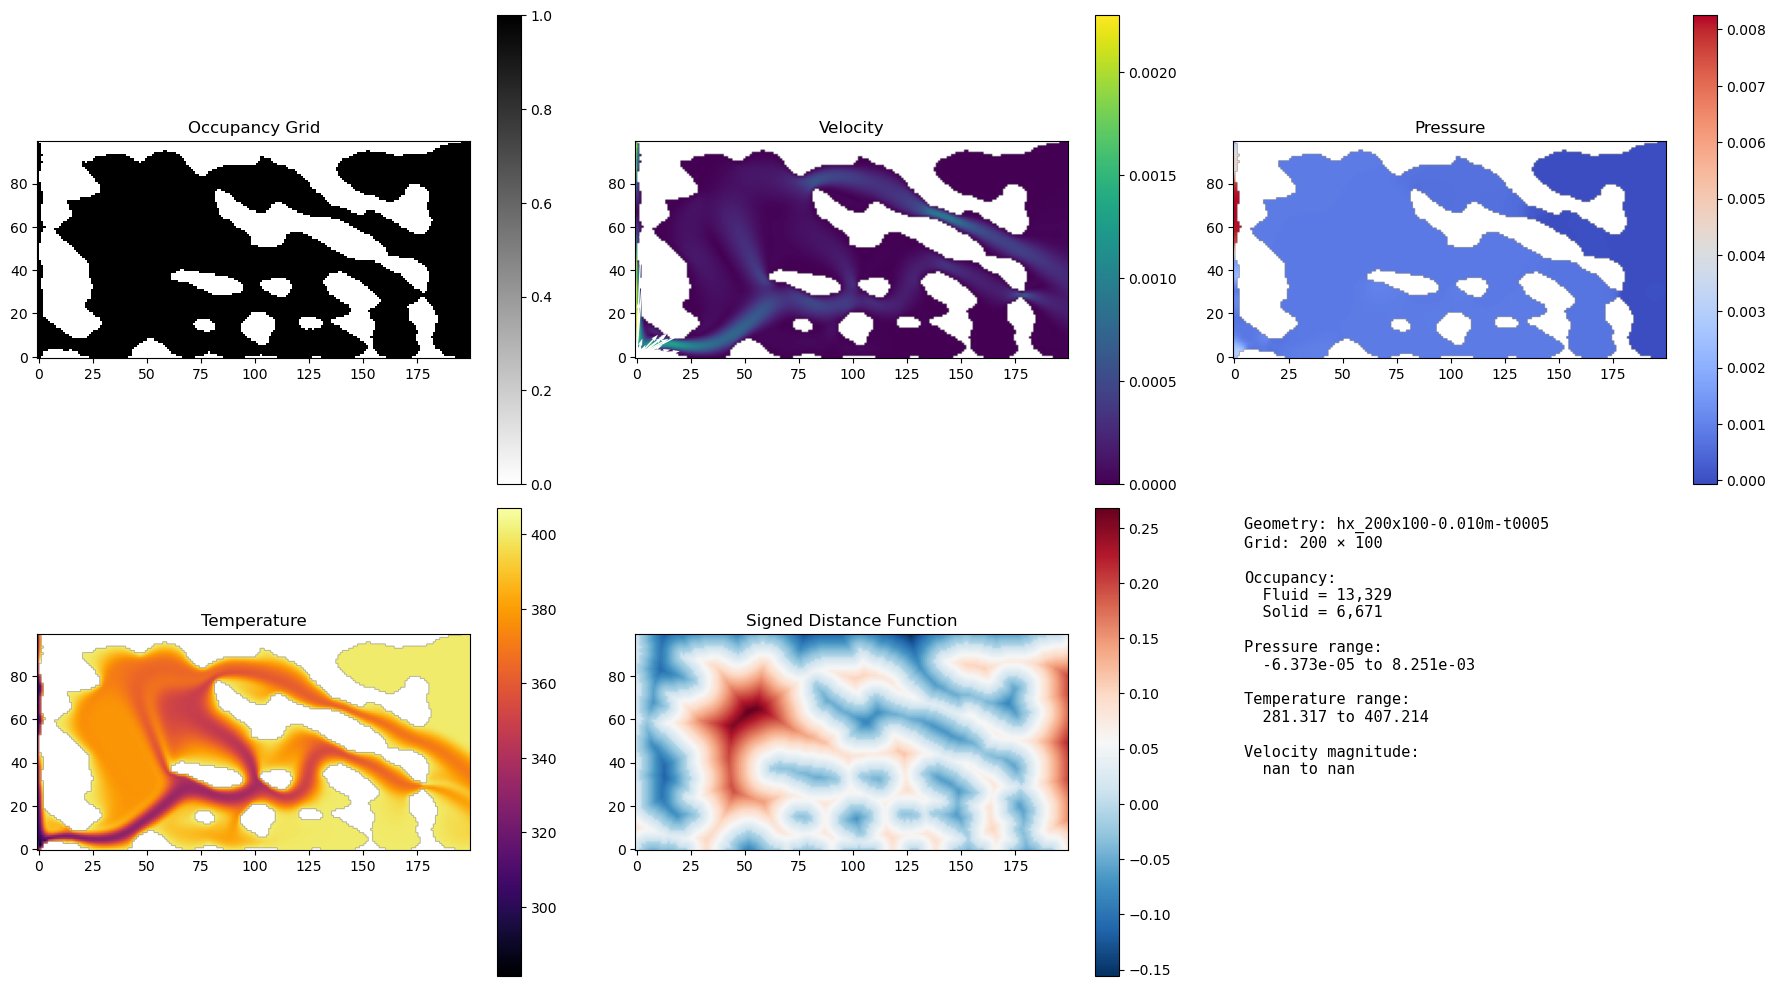

In [5]:
plot_heat_exchanger_parquet(
    "dataset/hx_200x100-0.010m-t0005.parquet"
)